# 说明：基于 BAM 的 reads 级联合突变统计

## 用途
从已完成过滤和位置排序的 BAM 中，统计指定参考坐标的 **联合碱基类型（haplotype）**，例如两个位点得到 `AA/AG/GA/GG` 的计数与比例。
该方法保留 reads 级联合信息，适用于链式/连锁突变分析。

## 输入要求
- BAM 已完成质量过滤与 sort by position。
- 参考序列名（contig）与坐标明确。

## 核心参数（在代码单元中修改）
- `bam_path`：BAM 文件路径。
- `ref_name`：参考序列名（如 `TAA`）。
- `positions_1based`：1-based 坐标列表，顺序即输出 haplotype 的顺序。
- `mapq_min` / `baseq_min`：比对与碱基质量阈值。
- `use_read1_only`：PE 数据避免双计数可设为 `True`。

## 统计规则
- 只统计 **同时覆盖所有位点** 的 reads。
- 对反向链 reads 做互补，保证与参考方向一致。
- CIGAR 中的缺失/跳跃（D/N）视为不覆盖该位点。

## 输出
- 扫描 reads 数、覆盖所有位点的 reads 数。
- 各 haplotype 的计数与比例。


# Read-level haplotype counts from BAM

This notebook counts joint haplotypes across multiple reference positions using a sorted BAM.
It keeps read-level information (not pileup counts) and reports joint base patterns like `AA`, `AG`, `GA`, `GG`.


In [10]:
import pysam
from collections import Counter

# Inputs
bam_path = "../demo_files/TAA_1_cutoff_0_bwa_sort.bam"
ref_name = "TAA"
positions_1based = [120, 121, 122, 123]

# Filters
mapq_min = 20
baseq_min = 20
use_read1_only = True  # set True to avoid double counting in paired-end
skip_secondary = True
skip_supplementary = True
skip_duplicates = True


In [11]:
COMP = {"A": "T", "C": "G", "G": "C", "T": "A", "N": "N"}


def complement_base(base):
    return COMP.get(base.upper(), base.upper())


def haplotype_from_read(read, pos_list0, baseq_min):
    pos_set = set(pos_list0)
    pos_to_base = {}
    seq = read.query_sequence
    quals = read.query_qualities

    for qpos, rpos in read.get_aligned_pairs(matches_only=False):
        if rpos is None or qpos is None:
            continue
        if rpos in pos_set:
            base = seq[qpos]
            if quals is not None and quals[qpos] < baseq_min:
                continue
            if read.is_reverse:
                base = complement_base(base)
            pos_to_base[rpos] = base.upper()

    if len(pos_to_base) != len(pos_set):
        return None
    return "".join(pos_to_base[p] for p in pos_list0)


pos_list0 = [p - 1 for p in positions_1based]
min_pos0 = min(pos_list0)
max_pos0 = max(pos_list0)

counts = Counter()
total_reads = 0
kept_reads = 0

with pysam.AlignmentFile(bam_path, "rb") as bam:
    for read in bam.fetch(ref_name, min_pos0, max_pos0 + 1):
        total_reads += 1
        if read.is_unmapped:
            continue
        if skip_secondary and read.is_secondary:
            continue
        if skip_supplementary and read.is_supplementary:
            continue
        if skip_duplicates and read.is_duplicate:
            continue
        if use_read1_only and not read.is_read1:
            continue
        if read.mapping_quality < mapq_min:
            continue

        hap = haplotype_from_read(read, pos_list0, baseq_min)
        if hap is None:
            continue
        counts[hap] += 1
        kept_reads += 1

print("Positions (1-based):", positions_1based)
print("Total reads scanned:", total_reads)
print("Reads with full coverage:", kept_reads)
print("Haplotype counts:")
total = sum(counts.values())
for hap, c in counts.most_common():
    frac = c / total if total else 0
    print(f"{hap}	{c}	{frac:.4f}")


Positions (1-based): [120, 121, 122, 123]
Total reads scanned: 155385
Reads with full coverage: 82249
Haplotype counts:
CACC	80702	0.9812
CGCC	1511	0.0184
TACC	10	0.0001
CACT	9	0.0001
CATC	7	0.0001
CACA	3	0.0000
CACG	2	0.0000
GACC	2	0.0000
CGCT	1	0.0000
CTCC	1	0.0000
CAGC	1	0.0000


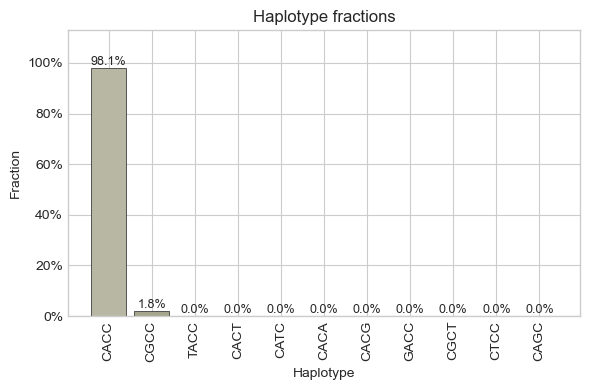

In [12]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

if not counts:
    print("No haplotypes to plot.")
else:
    haps = [h for h, _ in counts.most_common()]
    vals = [counts[h] for h in haps]
    total = sum(vals)
    fracs = [v / total for v in vals]

    plt.style.use("seaborn-v0_8-whitegrid")
    fig, ax = plt.subplots(figsize=(6, 4))
    palette = [
        "#B7B7A4",
        "#A5A58D",
        "#6B705C",
        "#CB997E",
        "#DDBEA9",
        "#FFE8D6",
        "#B5838D",
        "#6D6875",
    ]
    colors = [palette[i % len(palette)] for i in range(len(haps))]
    bars = ax.bar(haps, fracs, color=colors, edgecolor="#1f1f1f", linewidth=0.5)
    ax.set_ylim(0, max(fracs) * 1.15 if fracs else 1)
    ax.set_xlabel("Haplotype")
    ax.set_ylabel("Fraction")
    ax.set_title("Haplotype fractions")
    ax.tick_params(axis="x", rotation=90)
    ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"{y:.0%}"))

    for bar, f in zip(bars, fracs):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f"{f:.1%}",
            ha="center",
            va="bottom",
            fontsize=9,
        )

    plt.tight_layout()
    plt.show()


Notes:
- `positions_1based` is 1-based and the haplotype order follows this list.
- Deletions or skipped positions (CIGAR D/N) are ignored; a read must cover all positions.
- If you need fragment-level counting, set `use_read1_only = True` or implement read-pair merging.
